# 02 · Order Agent with Local Tools

## 🎯 Goal

Build a useful Order agent with two ordinary Python functions and inspect how
a multi-step request moves through the agent loop.

## 🧰 Setup

The workshop helper keeps credentials and tracing out of the lesson.

In [1]:
import helper
helper.setup()

from google.adk.agents import Agent
from workshop import MODEL, get_order, list_orders, run_agent, setup_workshop, show_source, show_text

workshop = setup_workshop("order-agent-local-tools")

✅ Workshop ready · Gemini configured · Phoenix tracing enabled


## Scenario

We will ask the same precise Order question in every comparison notebook.

In [2]:
ORDER_PROMPT = (
    "Find my most recent order from July 1 through July 31, 2026. "
    "Tell me its status, total, and every item's name and quantity."
)
BASE_INSTRUCTION = (
    "Help customers answer order questions using the available tools. "
    "Use only returned information, and clearly say when information is missing."
)
show_text("Customer request", ORDER_PROMPT)
show_text("System instruction", BASE_INSTRUCTION)

╭─────────────────────────────────────────────── Customer request ────────────────────────────────────────────────╮
│ Find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name   │
│ and quantity.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── System instruction ───────────────────────────────────────────────╮
│ Help customers answer order questions using the available tools. Use only returned information, and clearly say │
│ when information is missing.                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Mechanism: meet the tools

`list_orders` finds summaries. `get_order` retrieves the full record for one
returned ID. The functions hide HTTP details, but we can still inspect their
real source.

In [3]:
show_source(list_orders)

def list_orders(start_date: str, end_date: str) -> list[dict[str, Any]]:                                           
    """List order summaries for an inclusive YYYY-MM-DD date range."""                                             
                                                                                                                   
    try:                                                                                                           
        start = date.fromisoformat(start_date)                                                                     
        end = date.fromisoformat(end_date)                                                                         
    except ValueError as error:                                                                                    
        raise ValueError("dates must use YYYY-MM-DD format") from error                                            
    if start > end:                                                                                                
        raise ValueError("start_date must not be after end_date")                                                  
    payload = _get_json(                                                                                           
        "/v1/orders",                                                                                              
        params={"start_date": start.isoformat(), "end_date": end.isoformat()},                                     
    )                                                                                                              
    if not isinstance(payload, list) or not all(                                                                   
        isinstance(row, dict) for row in payload                                                                   
    ):                                                                                                             
        raise OrderAPIError("The teaching Orders service returned invalid summaries.")                             
    return payload

In [4]:
show_source(get_order)

def get_order(order_id: str) -> dict[str, Any]:                                                                    
    """Retrieve full details for one synthetic order ID."""                                                        
                                                                                                                   
    if ORDER_ID_PATTERN.fullmatch(order_id) is None:                                                               
        raise ValueError("order_id must match WM-DEMO-####")                                                       
    payload = _get_json(f"/v1/orders/{order_id}")                                                                  
    if not isinstance(payload, dict):                                                                              
        raise OrderAPIError("The teaching Orders service returned invalid details.")                               
    return payload

In [5]:
order_agent = Agent(
    name="order_agent",
    model=MODEL,
    instruction=BASE_INSTRUCTION,
    tools=[list_orders, get_order],
)

## Run

▶️ Send the shared Order request through the local-tool baseline.

In [6]:
show_text("Customer request", ORDER_PROMPT)
local_result = await run_agent(
    order_agent,
    ORDER_PROMPT,
    session_id="02-local-order-tools",
    trace_name="02-order-local-tools",
)

╭─────────────────────────────────────────────── Customer request ────────────────────────────────────────────────╮
│ Find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name   │
│ and quantity.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Your most recent order from July 2026 is order ID WM-DEMO-1004, placed on July 19, 2026.

*   **Status:** Processing
*   **Total:** $291.00

**Items in this order:**
*   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White:** 1
*   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A:** 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/fd1d676176d2184121c07d4dad4abbdb)

## 🔎 Inspect the five-boundary loop

Follow the six captured views in order. The request crosses five boundaries:
**LLM call → tool call → LLM call → tool call → LLM call**.

#### 🔎 Order trace overview

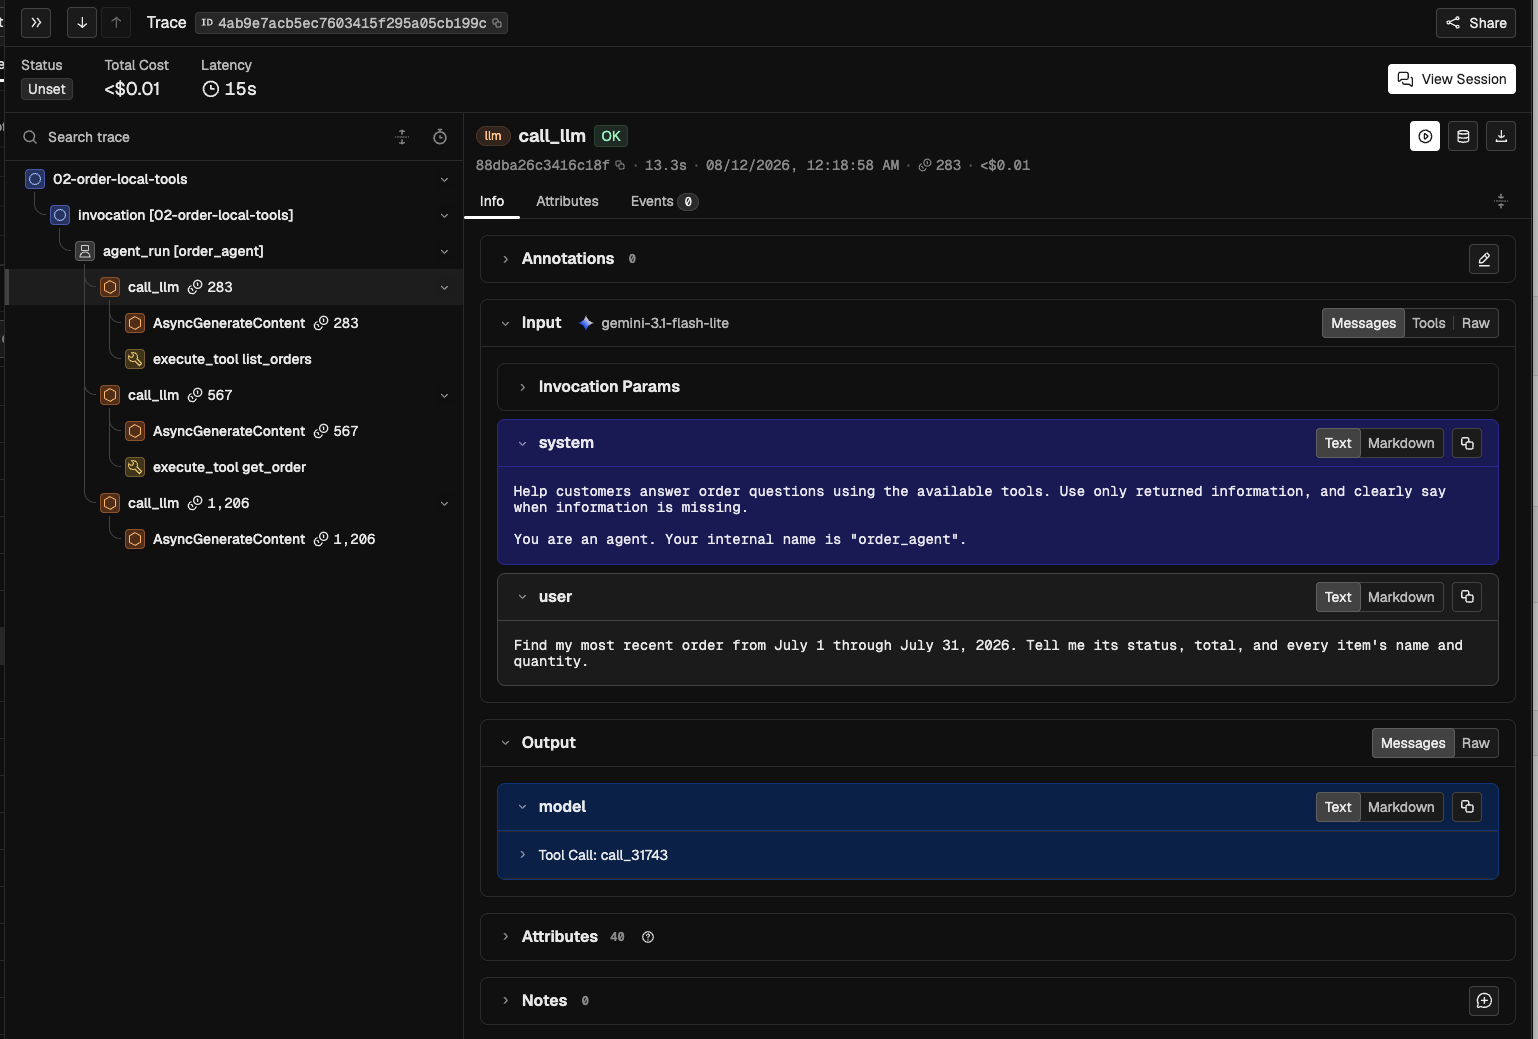

**What to notice**

The complete trace makes the five-boundary sequence visible: 3 LLM calls and 2 tool calls, both ordinary Python functions.

**Takeaway:** A two-tool workflow requires a new model decision after each intermediate result.

#### 🔎 Order tool definitions

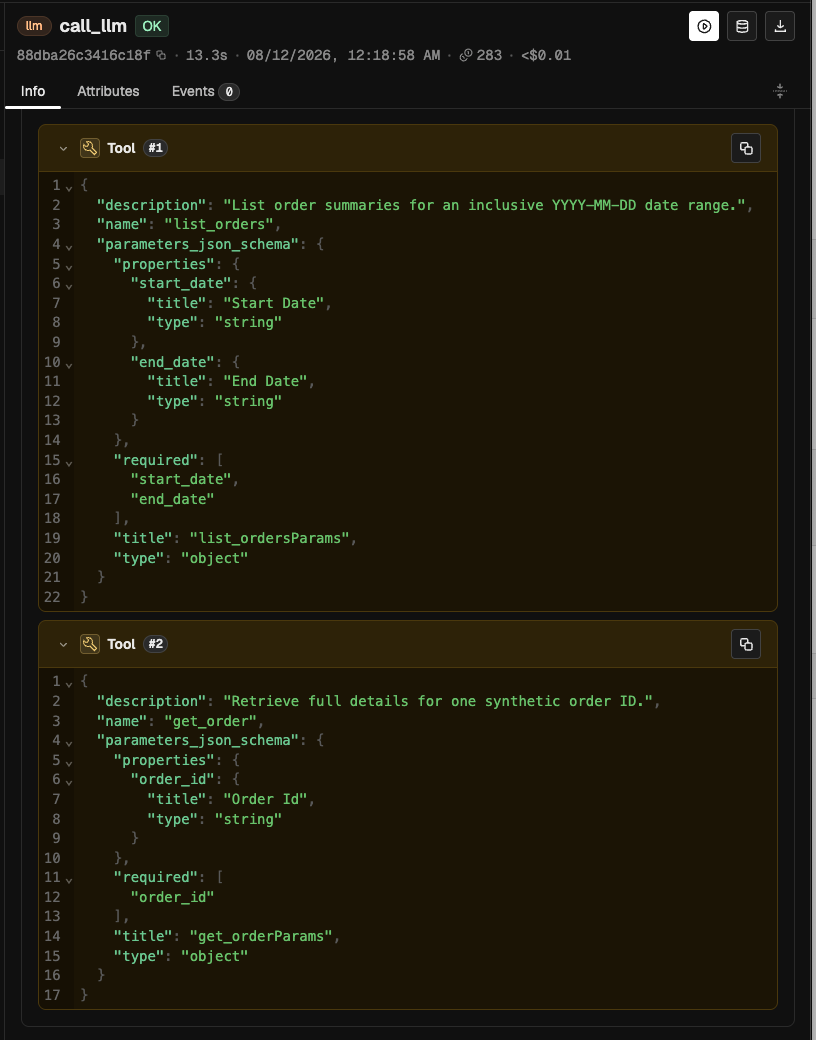

**What to notice**

The model context contains the `list_orders` and `get_order` names, descriptions, and JSON input schemas.

**Takeaway:** The model reasons from the published contracts—not from the Python implementation you inspected above.

#### 🔎 list_orders result

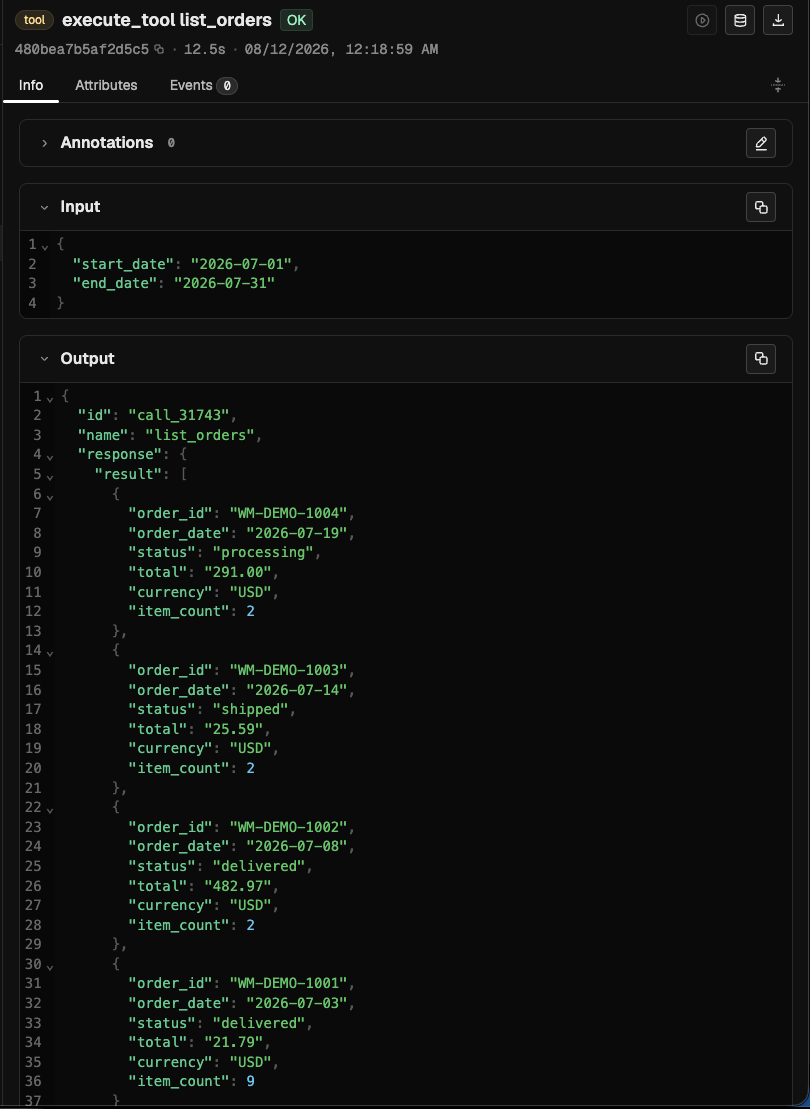

**What to notice**

The first tool call receives the requested date range and returns order summaries, including the ID needed for the next decision.

**Takeaway:** The summary response is intermediate evidence: it identifies the order, but it is not detailed enough for the final answer.

#### 🔎 Order context growth

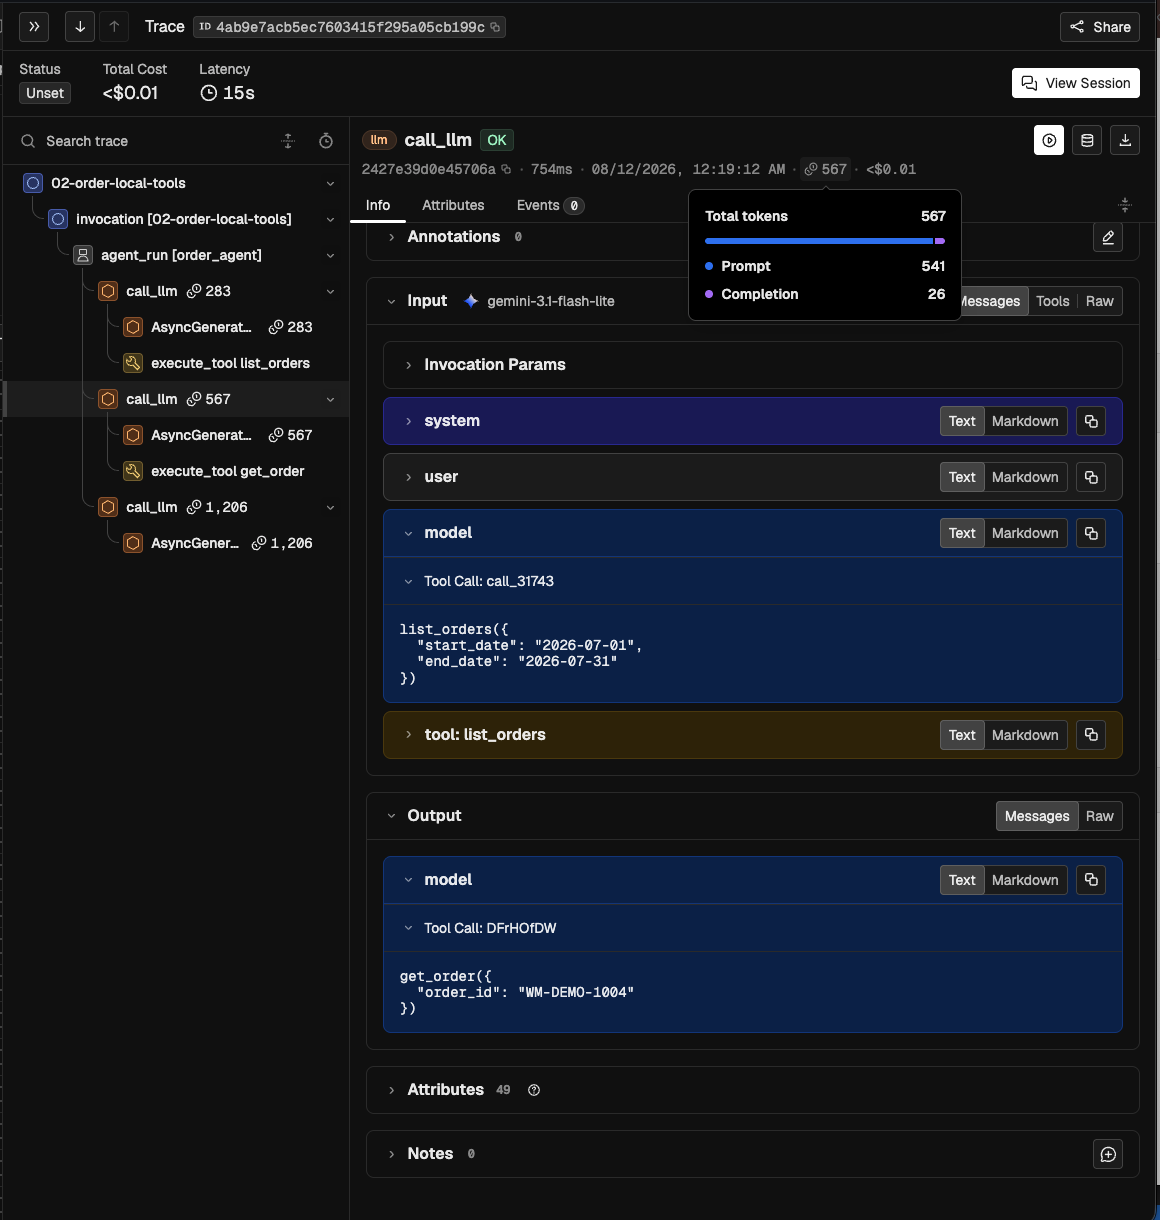

**What to notice**

Later model calls include the earlier tool results in message history, so context and prompt-token usage grow.

**Takeaway:** With direct tool calls, each result returns through the agent and makes the next model prompt larger.

#### 🔎 get_order result

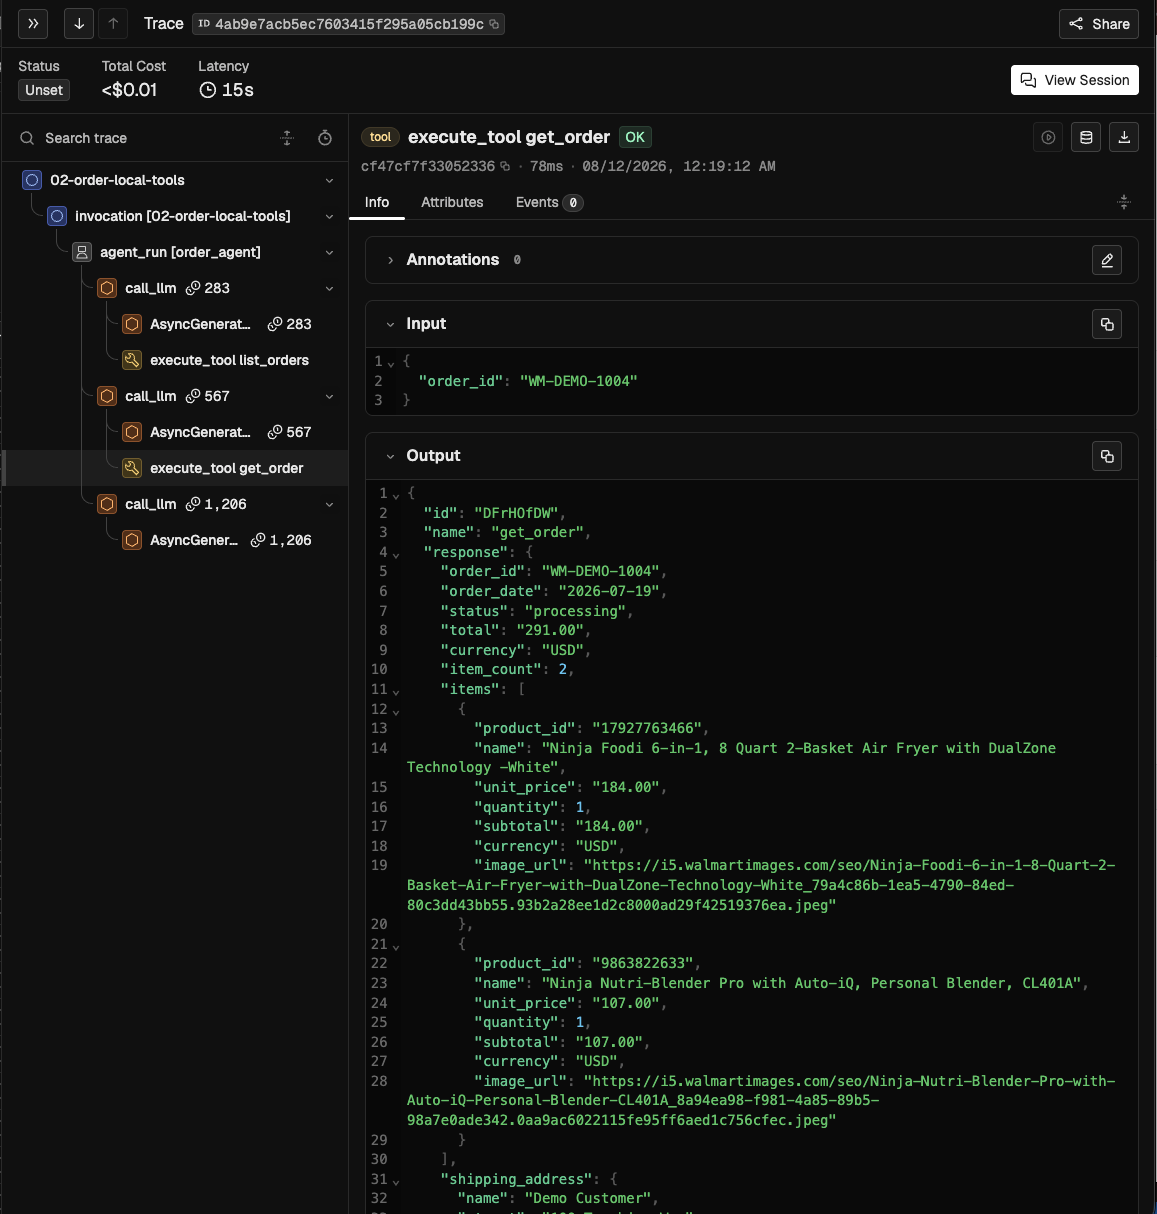

**What to notice**

The second tool call receives the selected order ID and returns the full record.

**Takeaway:** Only the full record provides the item-level evidence requested by the customer.

#### 🔎 Order final answer

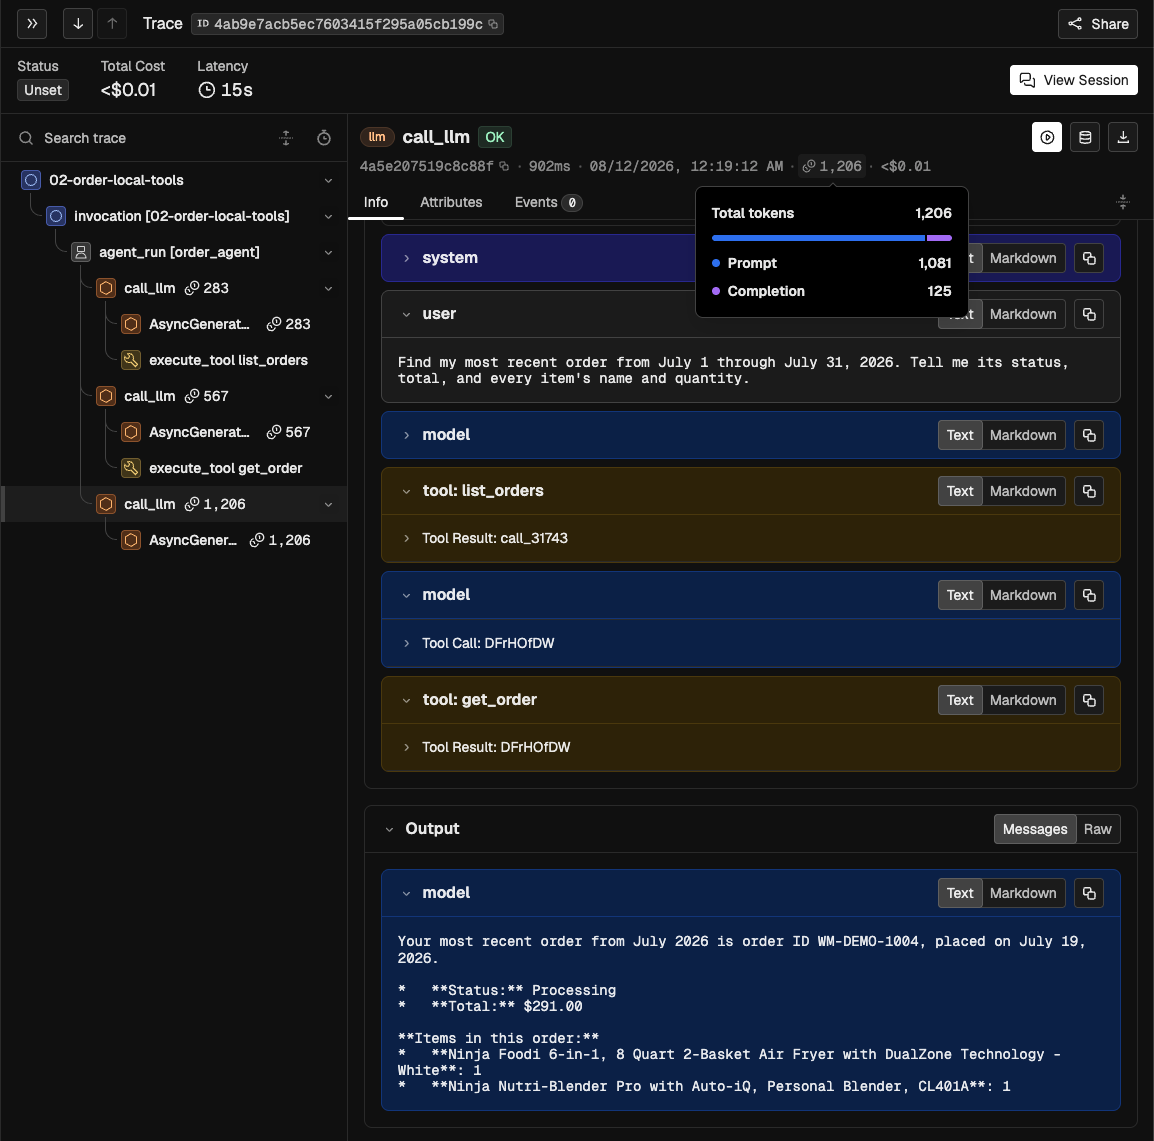

**What to notice**

The final model call reads both tool results and writes the grounded answer.

**Takeaway:** The answer is grounded because every reported status, total, name, and quantity came from tool output.

| Step | Boundary | Evidence | Tokens |
| --- | --- | --- | --- |
| 1 | LLM call | Chooses `list_orders` | 283 total |
| 2 | Tool call | Date range in; summaries out | Output becomes context for model call 2 |
| 3 | LLM call | Reads summaries; chooses `get_order` | 567 total = 541 prompt + 26 completion |
| 4 | Tool call | Order ID in; full record out | Output becomes context for model call 3 |
| 5 | LLM call | Reads both results; writes answer | 1,206 total = 1,081 prompt + 125 completion |

The later model calls include the earlier tool results in message history, so
context and prompt-token usage grow. Tool output is not model completion text;
it is evidence appended to the conversation before the next model call.

## ✅ Checkpoint

Great start—you now have a complete Order agent and a fair baseline for the
next notebook.